# ASL Recognition - Multi-Model Comparison Study

**Models Compared:** EfficientNetB0, MobileNetV2, VGG16, Xception  
**Training Strategy:** Two-phase (frozen base → fine-tuning)  
**Dataset:** ASL Alphabet (87,000 images, 29 classes)

This notebook trains and compares 4 different CNN architectures for American Sign Language recognition.

In [6]:
import os
import gc
import time
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0, MobileNetV2, VGG16, Xception
from tensorflow.keras.applications import efficientnet, mobilenet_v2, vgg16, xception
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras import backend as K
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Enable mixed precision for faster training
tf.keras.mixed_precision.set_global_policy('mixed_float16')

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")
print(f"Mixed Precision: {tf.keras.mixed_precision.global_policy().name}")

TensorFlow: 2.16.2
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mixed Precision: mixed_float16


In [7]:
# ============================================================
# CONFIGURATION
# ============================================================

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 29

# Two-phase training configuration
PHASE1_EPOCHS = 12      # Frozen base training
PHASE2_EPOCHS = 8       # Fine-tuning phase
PHASE1_LR = 1e-3
PHASE2_LR = 1e-5

# Paths
TRAIN_DIR = '../dataset/asl_alphabet_train/asl_alphabet_train'
MODEL_SAVE_DIR = '../models'
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

# Class labels
CLASS_LABELS = [
    'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M',
    'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z',
    'del', 'nothing', 'space'
]

# Model configurations - 4 models to compare
MODEL_CONFIGS = {
    'EfficientNetB0': {
        'base_model': EfficientNetB0,
        'preprocess': efficientnet.preprocess_input,
        'unfreeze_layers': 30,
    },
    'MobileNetV2': {
        'base_model': MobileNetV2,
        'preprocess': mobilenet_v2.preprocess_input,
        'unfreeze_layers': 40,
    },
    'VGG16': {
        'base_model': VGG16,
        'preprocess': vgg16.preprocess_input,
        'unfreeze_layers': 8,
    },
    'Xception': {
        'base_model': Xception,
        'preprocess': xception.preprocess_input,
        'unfreeze_layers': 30,
    }
}

print(f"Models to train: {list(MODEL_CONFIGS.keys())}")
print(f"Phase 1: {PHASE1_EPOCHS} epochs | Phase 2: {PHASE2_EPOCHS} epochs")
print(f"Dataset exists: {os.path.exists(TRAIN_DIR)}")

Models to train: ['EfficientNetB0', 'MobileNetV2', 'VGG16', 'Xception']
Phase 1: 12 epochs | Phase 2: 8 epochs
Dataset exists: True


In [8]:
# ============================================================
# DATA GENERATORS
# ============================================================

def create_generators(preprocess_fn):
    """Create train and validation generators with preprocessing."""
    
    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_fn,
        rotation_range=15,
        width_shift_range=0.15,
        height_shift_range=0.15,
        zoom_range=0.15,
        shear_range=0.1,
        brightness_range=[0.8, 1.2],
        horizontal_flip=False,  # ASL signs are directional
        fill_mode='nearest',
        validation_split=0.2
    )
    
    val_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_fn,
        validation_split=0.2
    )
    
    train_gen = train_datagen.flow_from_directory(
        TRAIN_DIR,
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        subset='training',
        shuffle=True
    )
    
    val_gen = val_datagen.flow_from_directory(
        TRAIN_DIR,
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        subset='validation',
        shuffle=False
    )
    
    return train_gen, val_gen

# Test with first model's preprocessing
train_gen, val_gen = create_generators(efficientnet.preprocess_input)
print(f"Training samples: {train_gen.samples}")
print(f"Validation samples: {val_gen.samples}")

Found 61628 images belonging to 29 classes.
Found 15406 images belonging to 29 classes.
Training samples: 61628
Validation samples: 15406


In [9]:
# ============================================================
# MODEL CREATION & TRAINING FUNCTIONS
# ============================================================

def clear_memory():
    """Clear GPU/CPU memory between models."""
    K.clear_session()
    gc.collect()
    print("Memory cleared.")

def create_model(base_model_class, trainable_base=False):
    """Create a model with the specified base architecture."""
    
    base_model = base_model_class(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base_model.trainable = trainable_base
    
    # Classification head
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.4)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(NUM_CLASSES, activation='softmax', dtype='float32')(x)
    
    model = Model(inputs=base_model.input, outputs=outputs)
    
    return model, base_model

def get_callbacks(model_name, phase):
    """Get callbacks for training."""
    return [
        EarlyStopping(
            monitor='val_accuracy',
            patience=4,
            restore_best_weights=True,
            verbose=1
        ),
        ModelCheckpoint(
            f'{MODEL_SAVE_DIR}/{model_name}_phase{phase}.keras',
            monitor='val_accuracy',
            save_best_only=True,
            verbose=0
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=2,
            min_lr=1e-7,
            verbose=1
        )
    ]

def train_model_two_phase(model_name, config):
    """Train a model using two-phase approach."""
    
    print(f"\n{'='*60}")
    print(f"TRAINING: {model_name}")
    print(f"{'='*60}")
    
    clear_memory()
    
    # Create data generators with model-specific preprocessing
    train_gen, val_gen = create_generators(config['preprocess'])
    
    # Phase 1: Frozen base
    print(f"\n--- Phase 1: Training Head (Frozen Base) ---")
    model, base_model = create_model(config['base_model'], trainable_base=False)
    model.compile(
        optimizer=Adam(learning_rate=PHASE1_LR),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    start_time = time.time()
    history1 = model.fit(
        train_gen,
        epochs=PHASE1_EPOCHS,
        validation_data=val_gen,
        callbacks=get_callbacks(model_name, 1),
        verbose=1
    )
    phase1_time = time.time() - start_time
    phase1_acc = max(history1.history['val_accuracy'])
    print(f"Phase 1 Best: {phase1_acc:.2%}")
    
    # Phase 2: Fine-tune top layers
    print(f"\n--- Phase 2: Fine-Tuning Top {config['unfreeze_layers']} Layers ---")
    for layer in base_model.layers[-config['unfreeze_layers']:]:
        layer.trainable = True
    
    model.compile(
        optimizer=Adam(learning_rate=PHASE2_LR),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    start_time = time.time()
    history2 = model.fit(
        train_gen,
        epochs=PHASE2_EPOCHS,
        validation_data=val_gen,
        callbacks=get_callbacks(model_name, 2),
        verbose=1
    )
    phase2_time = time.time() - start_time
    phase2_acc = max(history2.history['val_accuracy'])
    
    total_time = phase1_time + phase2_time
    print(f"\n✓ {model_name} Complete!")
    print(f"  Phase 1: {phase1_acc:.2%} | Phase 2: {phase2_acc:.2%}")
    print(f"  Total Time: {total_time/60:.1f} min")
    
    # Save final model
    model.save(f'{MODEL_SAVE_DIR}/{model_name}_final.keras')
    
    # Get model size
    params = model.count_params()
    
    # Combine histories
    combined_history = {
        'accuracy': history1.history['accuracy'] + history2.history['accuracy'],
        'val_accuracy': history1.history['val_accuracy'] + history2.history['val_accuracy'],
        'loss': history1.history['loss'] + history2.history['loss'],
        'val_loss': history1.history['val_loss'] + history2.history['val_loss'],
    }
    
    return {
        'phase1_acc': phase1_acc,
        'phase2_acc': phase2_acc,
        'final_acc': phase2_acc,
        'phase1_time': phase1_time,
        'phase2_time': phase2_time,
        'total_time': total_time,
        'params': params,
        'history': combined_history,
        'phase1_epochs': len(history1.history['accuracy'])
    }

print("Training functions defined.")

Training functions defined.


## Train All Models

Train each model using the two-phase approach: frozen base → fine-tuning.

In [10]:
# ============================================================
# TRAIN ALL MODELS
# ============================================================

results = {}
histories = {}

for model_name, config in MODEL_CONFIGS.items():
    result = train_model_two_phase(model_name, config)
    results[model_name] = result
    histories[model_name] = result['history']
    
    # Clear memory after each model
    clear_memory()

print("\n" + "="*60)
print("ALL MODELS TRAINED!")
print("="*60)


TRAINING: EfficientNetB0
Memory cleared.
Found 61628 images belonging to 29 classes.
Found 15406 images belonging to 29 classes.

--- Phase 1: Training Head (Frozen Base) ---
Epoch 1/12
1926/1926 ━━━━━━━━━━━━━━━━━━━━ 351s 179ms/step - accuracy: 0.8039 - loss: 1.3355 - val_accuracy: 0.8383 - val_loss: 1.7515 - learning_rate: 0.0010
Epoch 2/12
1926/1926 ━━━━━━━━━━━━━━━━━━━━ 344s 179ms/step - accuracy: 0.8691 - loss: 1.6478 - val_accuracy: 0.8631 - val_loss: 2.1014 - learning_rate: 0.0010
Epoch 3/12
1926/1926 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.8828 - loss: 2.1287
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1926/1926 ━━━━━━━━━━━━━━━━━━━━ 339s 176ms/step - accuracy: 0.8849 - loss: 2.3796 - val_accuracy: 0.8725 - val_loss: 3.6103 - learning_rate: 0.0010
Epoch 4/12
1926/1926 ━━━━━━━━━━━━━━━━━━━━ 330s 171ms/step - accuracy: 0.9170 - loss: 1.8604 - val_accuracy: 0.8973 - val_loss: 2.5248 - learning_rate: 5.0000e-04
Epoch 5/12
1926/1926 ━━━━━━━━━━━━

## Model Comparison Results

Compare all models across accuracy, training time, and model size.

In [11]:
# ============================================================
# RESULTS COMPARISON TABLE
# ============================================================

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Phase 1 Acc': [f"{results[m]['phase1_acc']:.2%}" for m in results],
    'Phase 2 Acc': [f"{results[m]['phase2_acc']:.2%}" for m in results],
    'Final Accuracy': [f"{results[m]['final_acc']:.2%}" for m in results],
    'Training Time (min)': [f"{results[m]['total_time']/60:.1f}" for m in results],
    'Parameters': [f"{results[m]['params']:,}" for m in results],
})

print("=" * 80)
print("MODEL COMPARISON SUMMARY")
print("=" * 80)
print(comparison_df.to_string(index=False))

# Find best model
best_model = max(results.keys(), key=lambda m: results[m]['final_acc'])
print(f"\n🏆 BEST MODEL: {best_model} with {results[best_model]['final_acc']:.2%} accuracy")

MODEL COMPARISON SUMMARY
         Model Phase 1 Acc Phase 2 Acc Final Accuracy Training Time (min) Parameters
EfficientNetB0      91.93%      93.04%         93.04%               115.0  4,849,344
   MobileNetV2      87.71%      92.85%         92.85%               110.1  3,057,757
         VGG16      82.88%      98.02%         98.02%               172.0 15,118,173
      Xception      82.44%      91.19%         91.19%               193.7 22,057,541

🏆 BEST MODEL: VGG16 with 98.02% accuracy


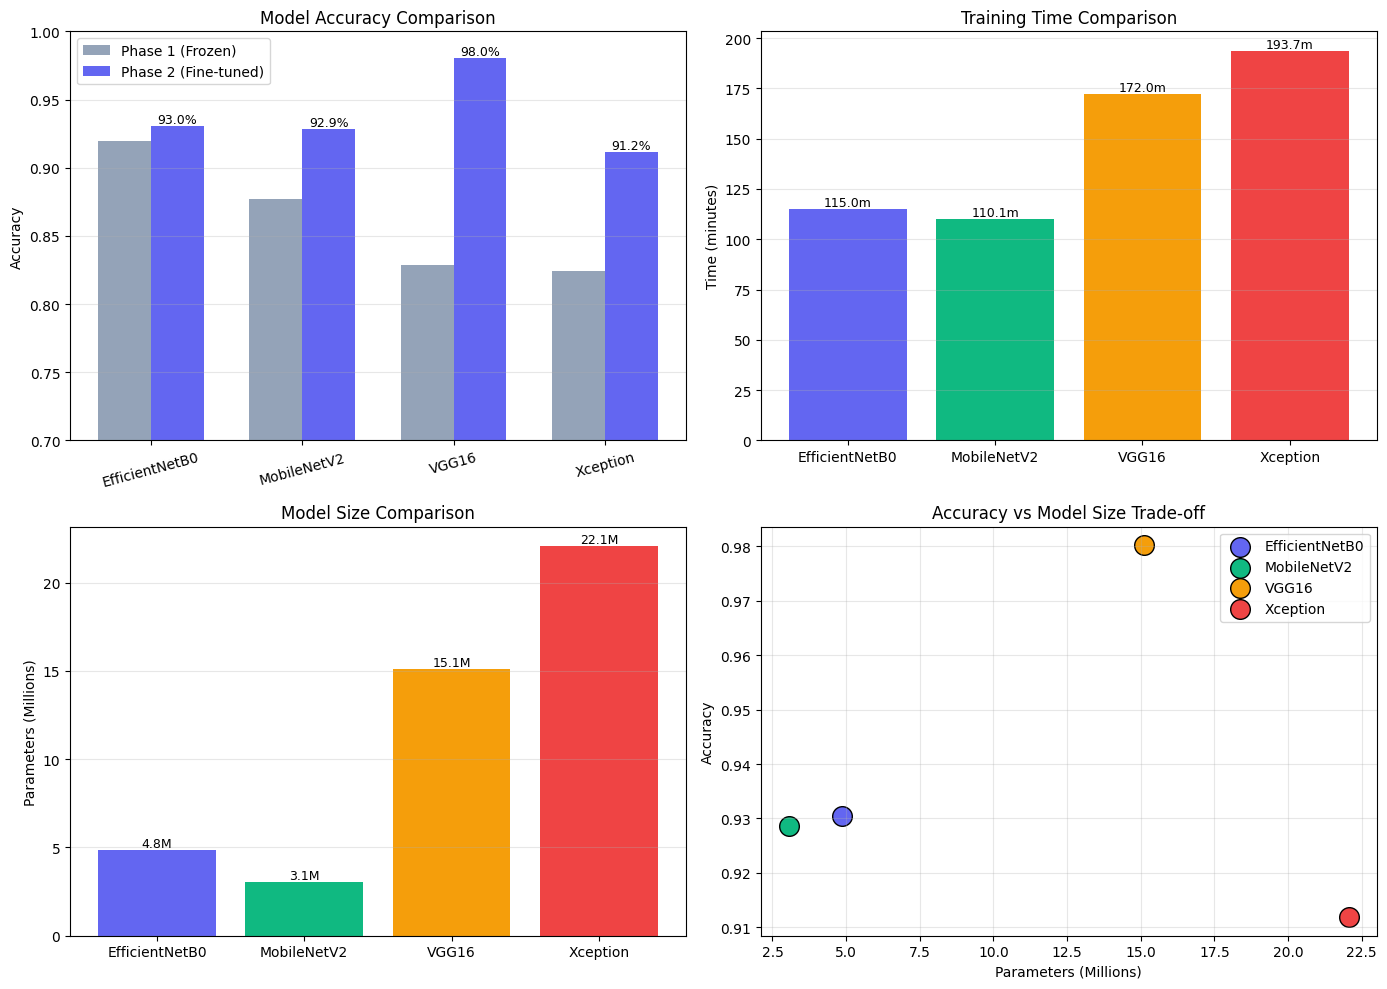

In [12]:
# ============================================================
# COMPARISON VISUALIZATIONS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = ['#6366f1', '#10b981', '#f59e0b', '#ef4444']
model_names = list(results.keys())

# 1. Accuracy Comparison (Bar Chart)
ax = axes[0, 0]
x = np.arange(len(model_names))
width = 0.35
phase1_accs = [results[m]['phase1_acc'] for m in model_names]
phase2_accs = [results[m]['phase2_acc'] for m in model_names]

bars1 = ax.bar(x - width/2, phase1_accs, width, label='Phase 1 (Frozen)', color='#94a3b8')
bars2 = ax.bar(x + width/2, phase2_accs, width, label='Phase 2 (Fine-tuned)', color='#6366f1')
ax.set_ylabel('Accuracy')
ax.set_title('Model Accuracy Comparison')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15)
ax.set_ylim([0.7, 1.0])
ax.legend()
ax.grid(axis='y', alpha=0.3)
for bar in bars2:
    ax.annotate(f'{bar.get_height():.1%}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=9)

# 2. Training Time Comparison
ax = axes[0, 1]
times = [results[m]['total_time']/60 for m in model_names]
bars = ax.bar(model_names, times, color=colors)
ax.set_ylabel('Time (minutes)')
ax.set_title('Training Time Comparison')
ax.grid(axis='y', alpha=0.3)
for bar, t in zip(bars, times):
    ax.annotate(f'{t:.1f}m', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=9)

# 3. Model Size Comparison
ax = axes[1, 0]
params = [results[m]['params']/1e6 for m in model_names]
bars = ax.bar(model_names, params, color=colors)
ax.set_ylabel('Parameters (Millions)')
ax.set_title('Model Size Comparison')
ax.grid(axis='y', alpha=0.3)
for bar, p in zip(bars, params):
    ax.annotate(f'{p:.1f}M', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=9)

# 4. Accuracy vs Size Trade-off (Scatter)
ax = axes[1, 1]
for i, m in enumerate(model_names):
    ax.scatter(results[m]['params']/1e6, results[m]['final_acc'], 
               s=200, c=colors[i], label=m, edgecolors='black', linewidth=1)
ax.set_xlabel('Parameters (Millions)')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy vs Model Size Trade-off')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{MODEL_SAVE_DIR}/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Training Curves Comparison

Visualize the training progress for all models.

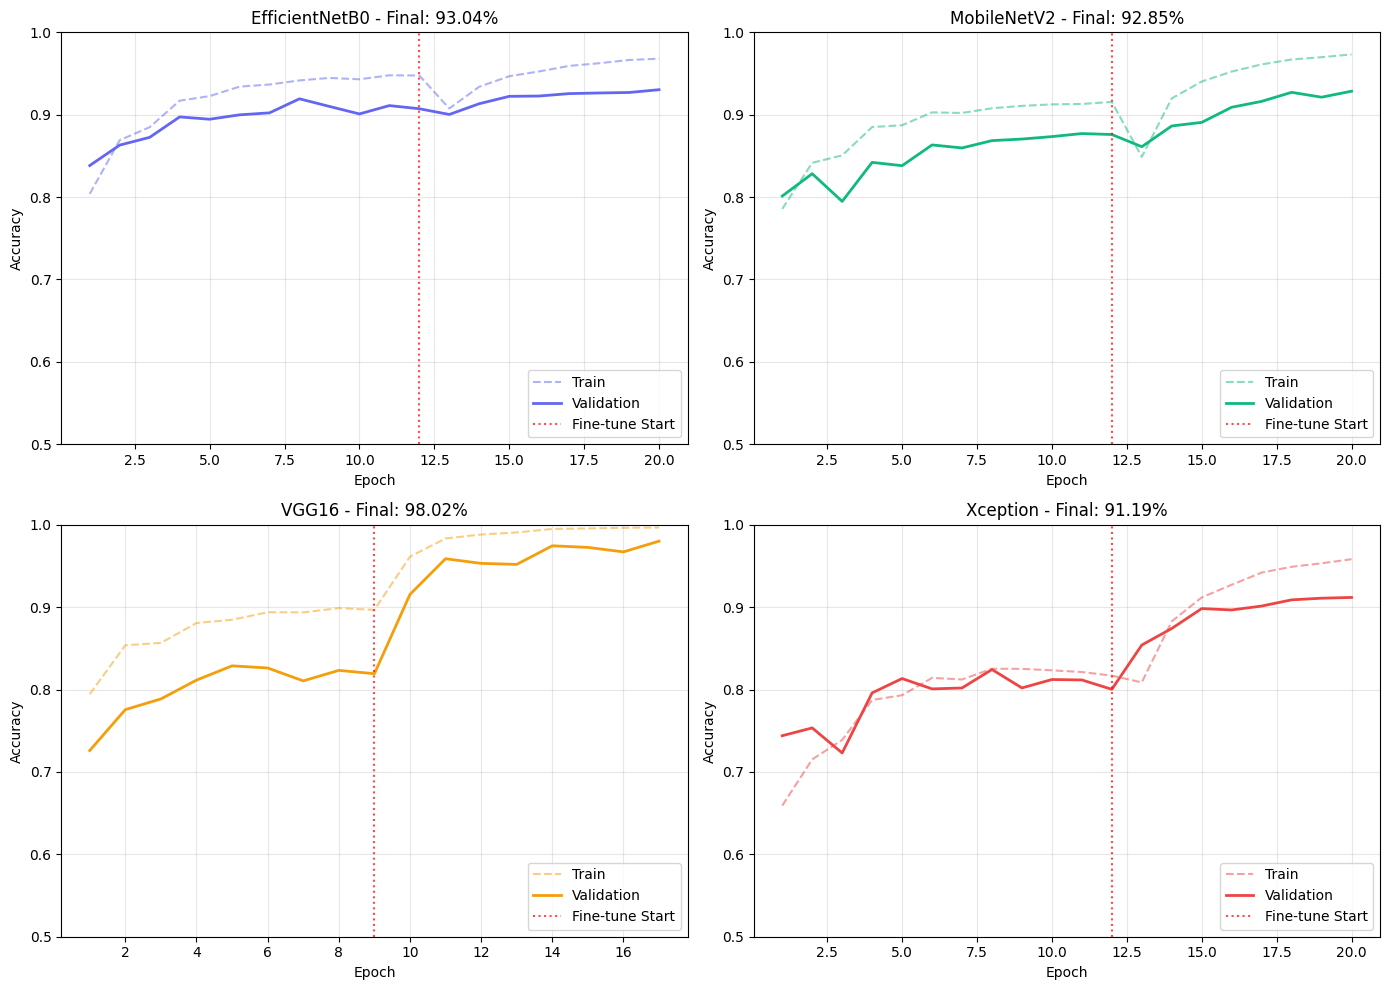

In [13]:
# ============================================================
# TRAINING CURVES FOR ALL MODELS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = ['#6366f1', '#10b981', '#f59e0b', '#ef4444']

for idx, (model_name, color) in enumerate(zip(model_names, colors)):
    ax = axes[idx // 2, idx % 2]
    history = histories[model_name]
    phase1_end = results[model_name]['phase1_epochs']
    
    epochs = range(1, len(history['val_accuracy']) + 1)
    
    ax.plot(epochs, history['accuracy'], '--', color=color, alpha=0.5, label='Train')
    ax.plot(epochs, history['val_accuracy'], '-', color=color, linewidth=2, label='Validation')
    ax.axvline(x=phase1_end, color='red', linestyle=':', alpha=0.7, label='Fine-tune Start')
    
    ax.set_title(f'{model_name} - Final: {results[model_name]["final_acc"]:.2%}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.set_ylim([0.5, 1.0])
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{MODEL_SAVE_DIR}/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Classification Reports & Confusion Matrices

Detailed per-class performance analysis for each model.

In [20]:
# ============================================================
# CLASSIFICATION REPORTS FOR ALL MODELS
# ============================================================

all_reports = {}

print("=" * 70)
print("CLASSIFICATION REPORTS")
print("=" * 70)

for model_name, config in MODEL_CONFIGS.items():
    print(f"\n{'='*50}")
    print(f"{model_name}")
    print(f"{'='*50}")
    
    clear_memory()
    
    # Try different file naming conventions
    possible_paths = [
        f'{MODEL_SAVE_DIR}/{model_name}_final.keras',
        f'{MODEL_SAVE_DIR}/{model_name.lower()}_final.keras',
        f'{MODEL_SAVE_DIR}/{model_name}_phase2.keras',
    ]
    
    model_path = None
    for path in possible_paths:
        if os.path.exists(path):
            model_path = path
            break
    
    if model_path is None:
        print(f"  ⚠️ Model file not found, skipping...")
        continue
    
    print(f"  Loading: {model_path}")
    
    try:
        # Load model
        model = load_model(model_path)
        
        # Create validation generator
        _, val_gen = create_generators(config['preprocess'])
        val_gen.reset()
        
        # Get predictions
        print("  Generating predictions...")
        preds = model.predict(val_gen, verbose=1)
        pred_classes = np.argmax(preds, axis=1)
        true_classes = val_gen.classes
        
        # Get class labels from generator (in correct order)
        class_indices = val_gen.class_indices
        idx_to_class = {v: k for k, v in class_indices.items()}
        labels_in_order = [idx_to_class[i] for i in range(len(class_indices))]
        
        # Classification report with explicit labels
        report = classification_report(
            true_classes, 
            pred_classes, 
            labels=list(range(len(labels_in_order))),
            target_names=labels_in_order
        )
        print(report)
        
        # Store for later
        all_reports[model_name] = {
            'pred_classes': pred_classes,
            'true_classes': true_classes,
            'accuracy': accuracy_score(true_classes, pred_classes),
            'labels': labels_in_order
        }
        
        del model
        
    except Exception as e:
        print(f"  ❌ Error: {e}")
        import traceback
        traceback.print_exc()
        continue

print(f"\n✓ Generated reports for {len(all_reports)} models")

CLASSIFICATION REPORTS

EfficientNetB0
Memory cleared.
  Loading: ../models/EfficientNetB0_final.keras
Found 61628 images belonging to 29 classes.
Found 15406 images belonging to 29 classes.
  Generating predictions...
482/482 ━━━━━━━━━━━━━━━━━━━━ 46s 89ms/step
              precision    recall  f1-score   support

           A       0.00      0.00      0.00         0
           B       0.00      0.00      0.00         0
           C       0.00      0.00      0.00         0
           D       1.00      0.91      0.95       406
           E       0.93      1.00      0.96       600
           F       1.00      1.00      1.00       600
           G       0.97      0.94      0.96       600
           H       0.89      1.00      0.94       600
           I       0.97      0.81      0.88       600
           J       0.90      0.91      0.90       600
           K       1.00      0.95      0.97       600
           L       0.99      1.00      0.99       600
           M       0.73      0.96  

/Users/sam/Desktop/Project Guys 2025:2026/Adetula/Codework/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/sam/Desktop/Project Guys 2025:2026/Adetula/Codework/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/sam/Desktop/Project Guys 2025:2026/Adetula/Codework/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero

Memory cleared.
  Loading: ../models/MobileNetV2_final.keras
Found 61628 images belonging to 29 classes.
Found 15406 images belonging to 29 classes.
  Generating predictions...
482/482 ━━━━━━━━━━━━━━━━━━━━ 32s 60ms/step
              precision    recall  f1-score   support

           A       0.00      0.00      0.00         0
           B       0.00      0.00      0.00         0
           C       0.00      0.00      0.00         0
           D       1.00      0.91      0.95       406
           E       0.83      0.97      0.89       600
           F       1.00      1.00      1.00       600
           G       0.98      0.98      0.98       600
           H       0.98      0.99      0.99       600
           I       0.97      0.85      0.90       600
           J       0.95      0.89      0.92       600
           K       1.00      0.98      0.99       600
           L       0.99      1.00      1.00       600
           M       0.92      0.97      0.95       600
           N       0.86

/Users/sam/Desktop/Project Guys 2025:2026/Adetula/Codework/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/sam/Desktop/Project Guys 2025:2026/Adetula/Codework/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/sam/Desktop/Project Guys 2025:2026/Adetula/Codework/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero

Memory cleared.
  Loading: ../models/VGG16_final.keras
Found 61628 images belonging to 29 classes.
Found 15406 images belonging to 29 classes.
  Generating predictions...
482/482 ━━━━━━━━━━━━━━━━━━━━ 86s 177ms/step
              precision    recall  f1-score   support

           A       0.00      0.00      0.00         0
           B       0.00      0.00      0.00         0
           C       0.00      0.00      0.00         0
           D       1.00      0.93      0.96       406
           E       0.98      1.00      0.99       600
           F       1.00      1.00      1.00       600
           G       1.00      1.00      1.00       600
           H       0.96      1.00      0.98       600
           I       0.99      0.99      0.99       600
           J       1.00      0.89      0.94       600
           K       1.00      1.00      1.00       600
           L       1.00      1.00      1.00       600
           M       0.96      1.00      0.98       600
           N       0.98     

/Users/sam/Desktop/Project Guys 2025:2026/Adetula/Codework/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/sam/Desktop/Project Guys 2025:2026/Adetula/Codework/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/sam/Desktop/Project Guys 2025:2026/Adetula/Codework/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero

Memory cleared.
  Loading: ../models/Xception_final.keras
Found 61628 images belonging to 29 classes.
Found 15406 images belonging to 29 classes.
  Generating predictions...
482/482 ━━━━━━━━━━━━━━━━━━━━ 100s 202ms/step
              precision    recall  f1-score   support

           A       0.00      0.00      0.00         0
           B       0.00      0.00      0.00         0
           C       0.00      0.00      0.00         0
           D       1.00      0.78      0.88       406
           E       0.92      0.97      0.94       600
           F       1.00      1.00      1.00       600
           G       0.92      0.99      0.95       600
           H       0.99      0.99      0.99       600
           I       0.94      0.74      0.83       600
           J       0.94      0.86      0.90       600
           K       0.97      0.97      0.97       600
           L       1.00      1.00      1.00       600
           M       0.72      0.99      0.83       600
           N       0.95 

/Users/sam/Desktop/Project Guys 2025:2026/Adetula/Codework/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/sam/Desktop/Project Guys 2025:2026/Adetula/Codework/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/sam/Desktop/Project Guys 2025:2026/Adetula/Codework/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero

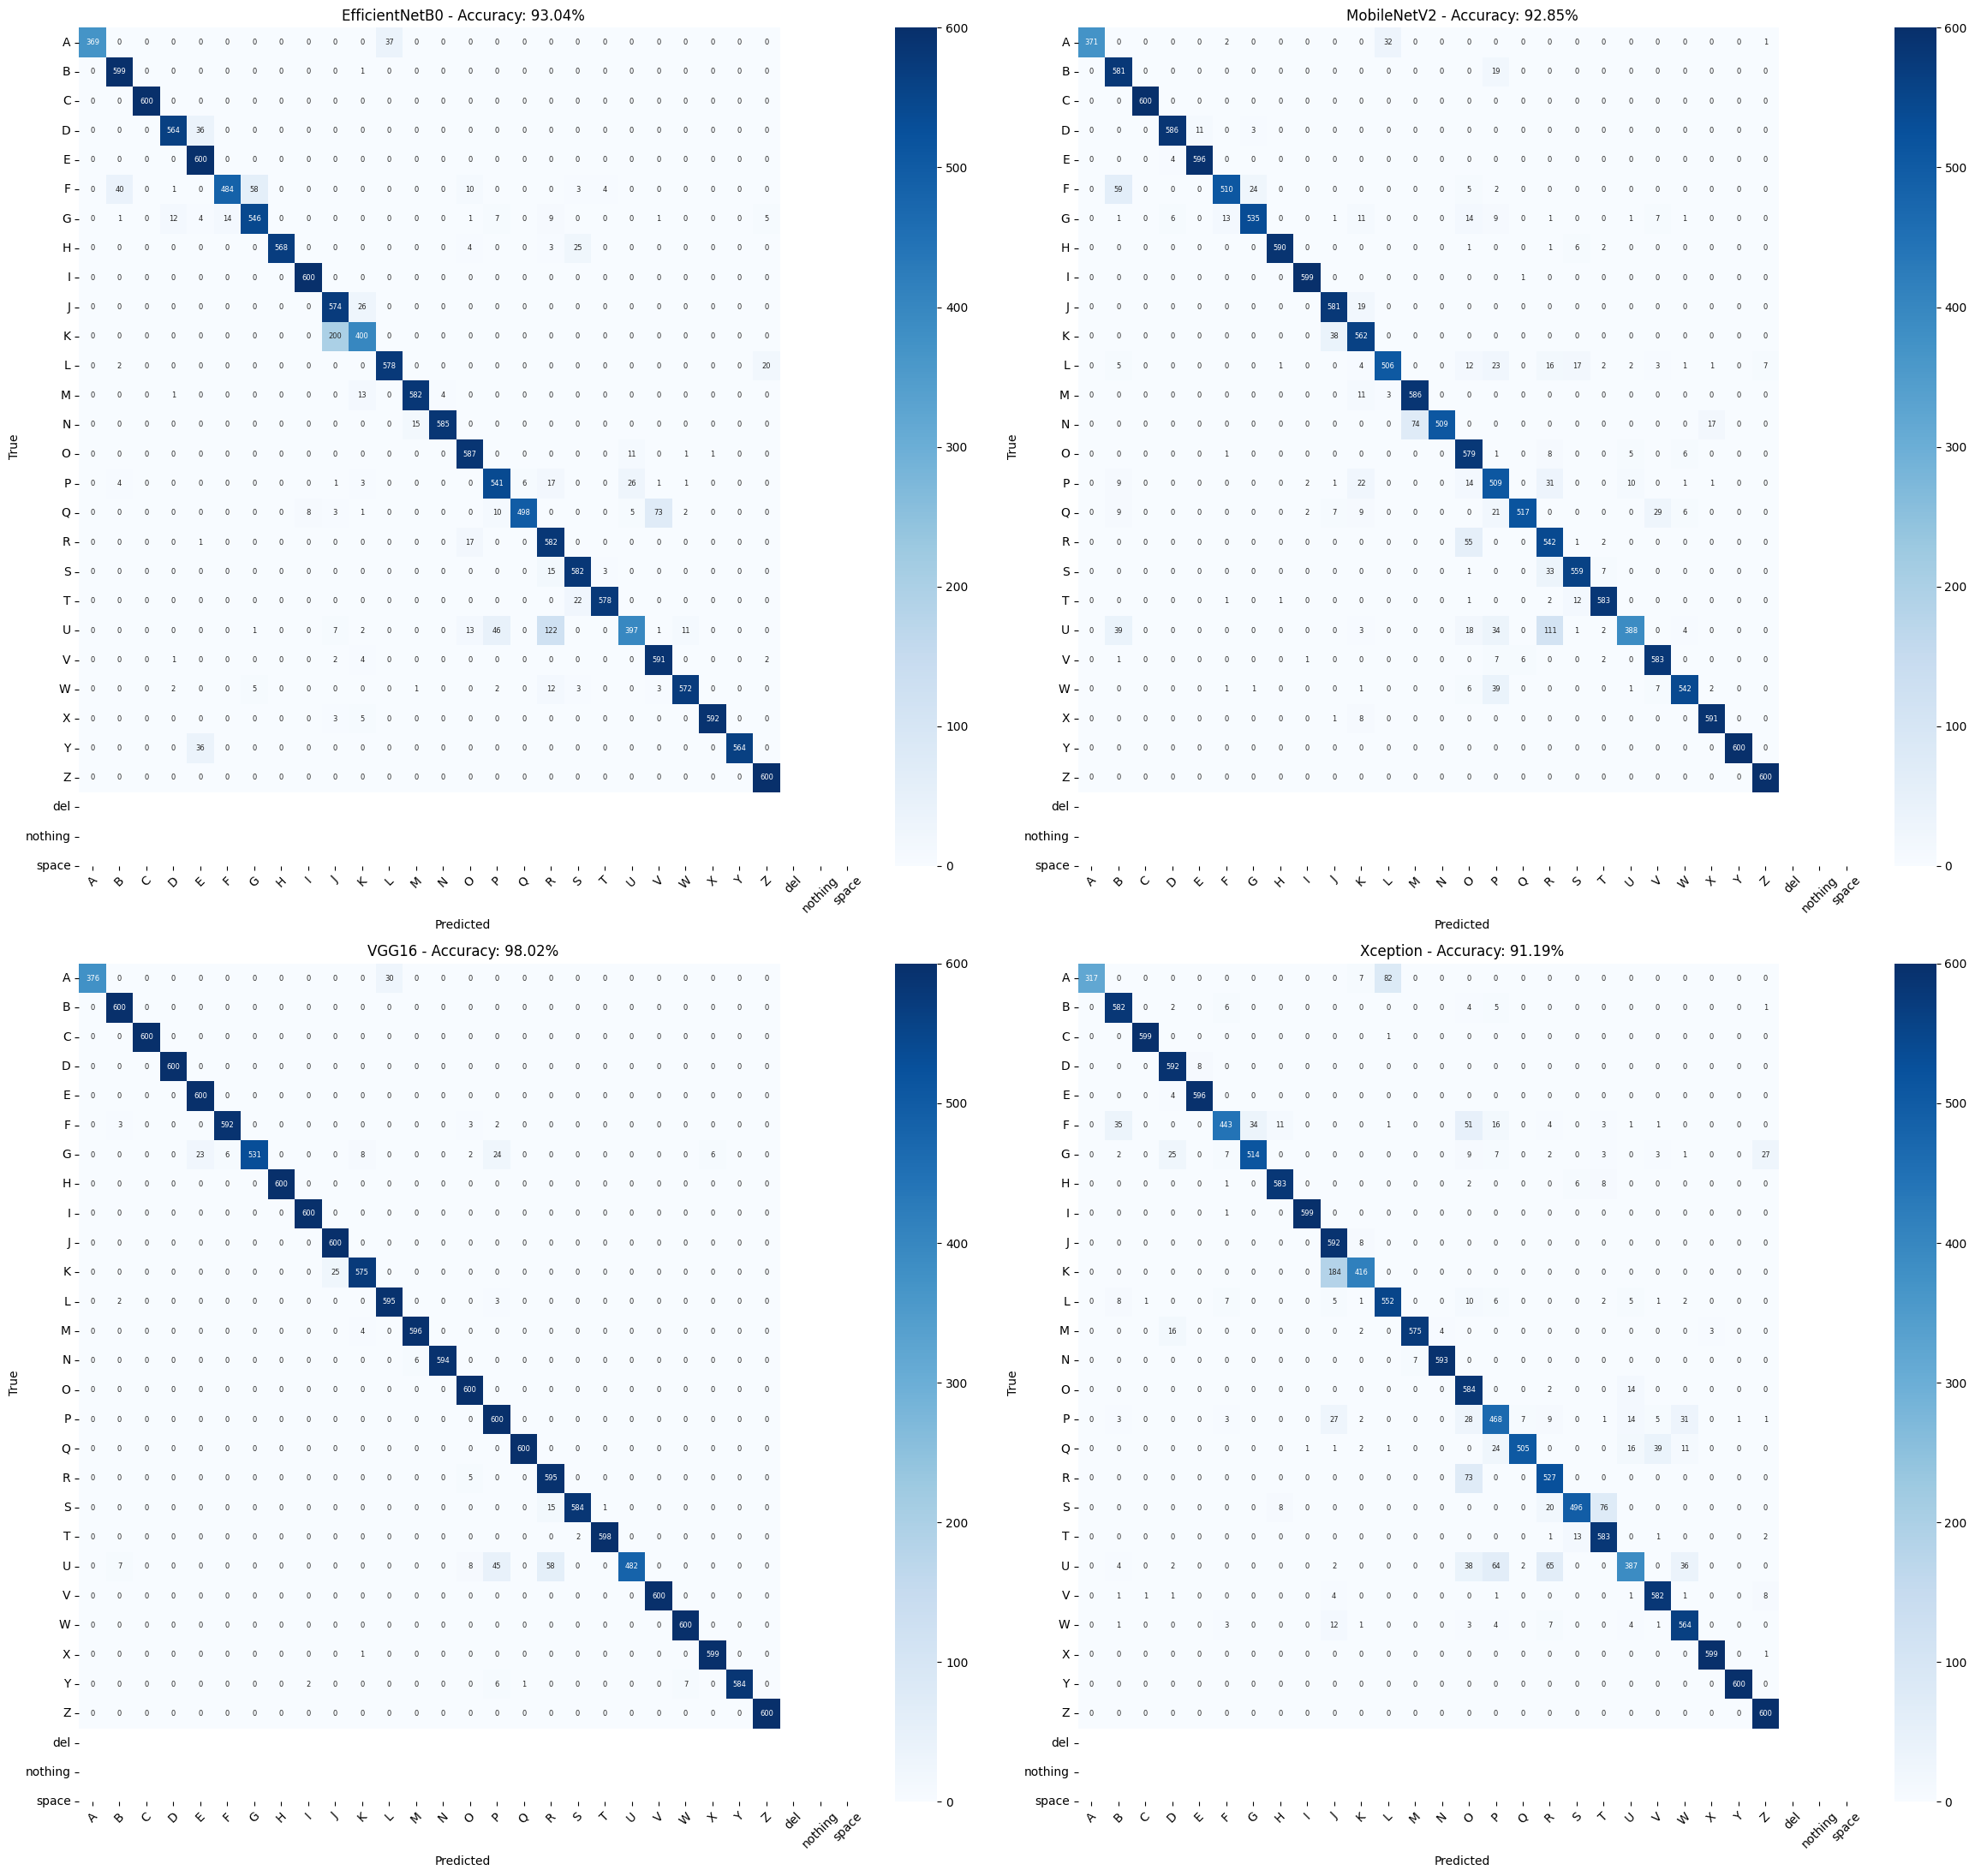

✓ Saved confusion matrices to ../models/confusion_matrices.png


: 

In [ ]:
# ============================================================
# CONFUSION MATRICES FOR ALL MODELS
# ============================================================

models_with_reports = list(all_reports.keys())
n_models = len(models_with_reports)

if n_models == 0:
    print("No models to plot confusion matrices for.")
else:
    n_cols = 2
    n_rows = (n_models + 1) // 2
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 11 * n_rows))
    if n_models == 1:
        axes = [axes]
    elif n_rows == 1:
        axes = axes.reshape(-1)
    else:
        axes = axes.flatten()

    for idx, model_name in enumerate(models_with_reports):
        ax = axes[idx]
        
        # Get labels for this model
        labels = all_reports[model_name].get('labels', CLASS_LABELS)
        
        cm = confusion_matrix(
            all_reports[model_name]['true_classes'],
            all_reports[model_name]['pred_classes']
        )
        
        sns.heatmap(
            cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=labels, 
            yticklabels=labels,
            ax=ax,
            annot_kws={"size": 6}
        )
        
        acc = all_reports[model_name]['accuracy']
        ax.set_title(f'{model_name} - Accuracy: {acc:.2%}', fontsize=12)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')
        ax.tick_params(axis='x', rotation=45)

    # Hide unused subplots
    for idx in range(n_models, len(axes)):
        axes[idx].set_visible(False)

    plt.tight_layout()
    plt.savefig(f'{MODEL_SAVE_DIR}/confusion_matrices.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved confusion matrices to {MODEL_SAVE_DIR}/confusion_matrices.png")

In [15]:
# ============================================================
# SAVE BEST MODEL FOR PRODUCTION
# ============================================================

# Find best model
best_model_name = max(results.keys(), key=lambda m: results[m]['final_acc'])
best_accuracy = results[best_model_name]['final_acc']

# Copy best model as production model
src = f'{MODEL_SAVE_DIR}/{best_model_name}_final.keras'
dst = f'{MODEL_SAVE_DIR}/best_asl_model.keras'

if os.path.exists(dst):
    backup = f'{MODEL_SAVE_DIR}/best_asl_model_backup.keras'
    shutil.move(dst, backup)
    print(f"Backed up previous model to: {backup}")

shutil.copy(src, dst)

print("\n" + "=" * 70)
print("TRAINING COMPLETE - FINAL SUMMARY")
print("=" * 70)

print(f"\n📊 Models Trained: {len(results)}")
print(f"📁 Dataset: {train_gen.samples + val_gen.samples:,} images, {NUM_CLASSES} classes")

print(f"\n🏆 Best Model: {best_model_name}")
print(f"   Accuracy: {best_accuracy:.2%}")
print(f"   Parameters: {results[best_model_name]['params']:,}")
print(f"   Training Time: {results[best_model_name]['total_time']/60:.1f} min")

print(f"\n💾 Production model saved: {dst}")

print("\n📈 All Model Results:")
for name in results:
    r = results[name]
    marker = "👑" if name == best_model_name else "  "
    print(f"{marker} {name}: {r['final_acc']:.2%} ({r['total_time']/60:.1f} min, {r['params']/1e6:.1f}M params)")

Backed up previous model to: ../models/best_asl_model_backup.keras

TRAINING COMPLETE - FINAL SUMMARY

📊 Models Trained: 4
📁 Dataset: 77,034 images, 29 classes

🏆 Best Model: VGG16
   Accuracy: 98.02%
   Parameters: 15,118,173
   Training Time: 172.0 min

💾 Production model saved: ../models/best_asl_model.keras

📈 All Model Results:
   EfficientNetB0: 93.04% (115.0 min, 4.8M params)
   MobileNetV2: 92.85% (110.1 min, 3.1M params)
👑 VGG16: 98.02% (172.0 min, 15.1M params)
   Xception: 91.19% (193.7 min, 22.1M params)
